In [1]:
"""
Breast Cancer Prediction with KNN
Author: [Your Name]
Description: Predict whether a breast tumor is malignant or benign using KNN
"""
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Malignant (1): {(df['target'] == 1).sum()}")
print(f"Benign (0): {(df['target'] == 0).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520


BASIC STATISTICS
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.0

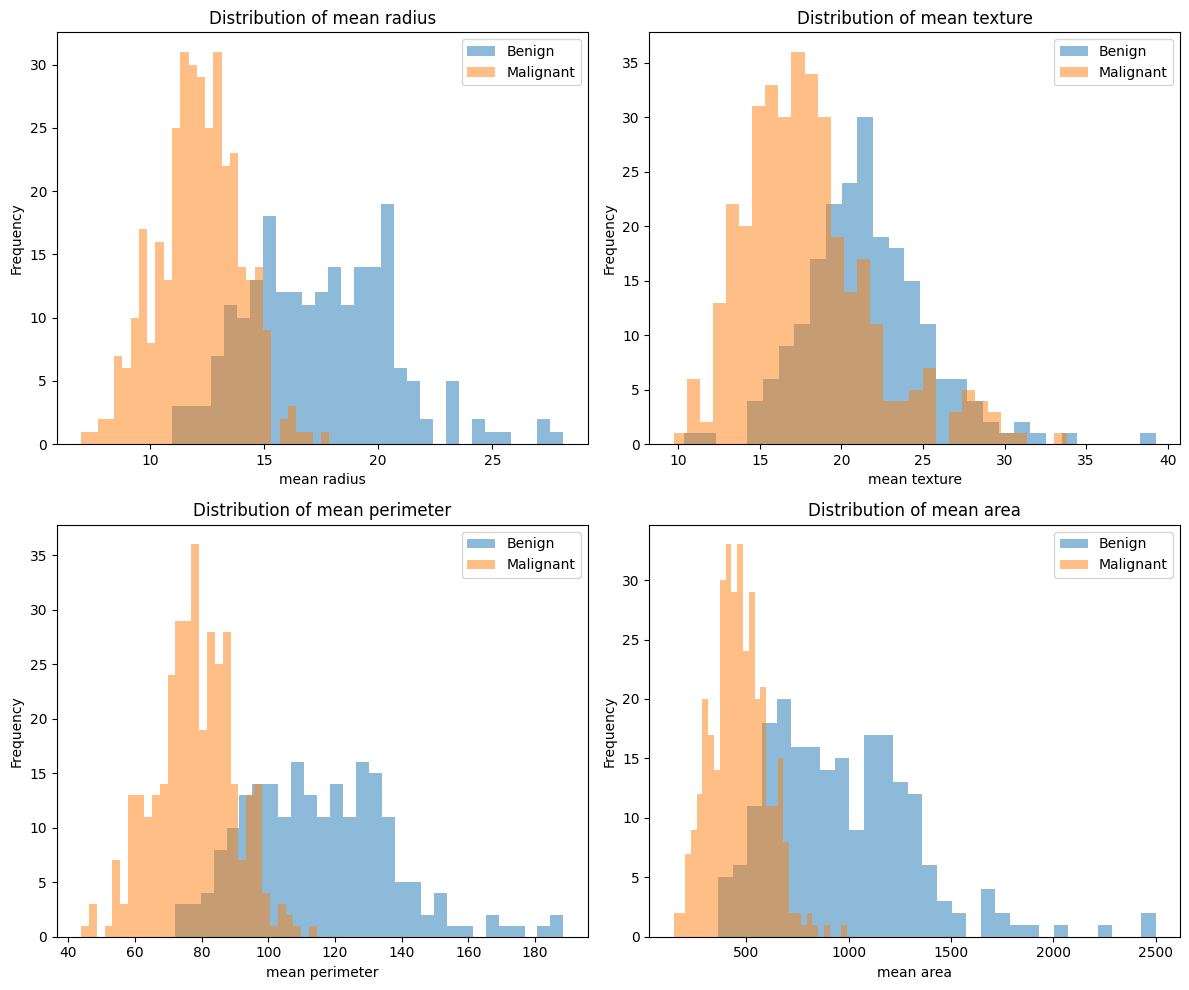

In [2]:
# STEP 2 - Data Exploration
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())
 
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])
 
# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['target'] == 0][feature], alpha=0.5, label='Benign', bins=30)
    axes[idx].hist(df[df['target'] == 1][feature], alpha=0.5, label='Malignant', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()

In [ ]:
# STEP 3 - Splitting the Data
#  Separate features and target
X = df.drop('target', axis=1)  # All columns except 'target'
y = df['target']  # Target column
 
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
 
# Split into training and testing sets
# random_state ensures reproducibility
# stratify=y ensures both sets have similar class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
 
print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")
 
# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Benign (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
 
print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Benign (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
1    285
0    170
Name: count, dtype: int64
  Benign (0): 170 (37.4%)
  Malignant (1): 285 (62.6%)

Test set target distribution:
target
1    72
0    42
Name: count, dtype: int64
  Benign (0): 42 (36.8%)
  Malignant (1): 72 (63.2%)


In [4]:
# STEP 4 - Training the KNN Model
# Create KNN classifier
# n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction
 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")
 
# Make predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")

KNN classifier trained successfully!
Number of neighbors (k): 5

Training predictions: 455
Test predictions: 114


In [5]:
# Step 5: Making Predictions

# Make predictions on the test set
y_test_pred = knn.predict(X_test)

# Compare predictions with actual values
print("Predictions vs Actual values:")
print(f"{'Index':<10} {'Predicted':<15} {'Actual':<15} {'Correct?':<10}")
print("-" * 50)

for i in range(min(10, len(y_test_pred))):  # Show first 10 examples
    correct = "✓" if y_test_pred[i] == y_test.iloc[i] else "✗"
    print(f"{i:<10} {y_test_pred[i]:<15} {y_test.iloc[i]:<15} {correct:<10}")

# Summary
correct_predictions = sum(y_test_pred == y_test)
total_predictions = len(y_test_pred)
print(f"\nCorrect predictions: {correct_predictions} / {total_predictions}")
print(f"Accuracy: {correct_predictions / total_predictions:.2%}")

Predictions vs Actual values:
Index      Predicted       Actual          Correct?  
--------------------------------------------------
0          0               0               ✓         
1          1               1               ✓         
2          0               0               ✓         
3          0               1               ✗         
4          0               0               ✓         
5          1               1               ✓         
6          1               1               ✓         
7          0               0               ✓         
8          0               0               ✓         
9          0               0               ✓         

Correct predictions: 104 / 114
Accuracy: 91.23%


In [32]:
print("First 10 test predictions:")

print(y_test_pred[:10])

print("\nFirst 10 actual values:")

print(y_test.iloc[:10].values)

First 10 test predictions:
[0 1 0 0 0 1 1 0 0 0]

First 10 actual values:
[0 1 0 1 0 1 1 0 0 0]


In [6]:
# Step 6: Evaluating Model Performance
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
 
print("\n=== Confusion Matrix ===")
print("                Predicted")
print("              Benign  Malignant")
print(f"Actual Benign    {test_confusion[0,0]:4d}      {test_confusion[0,1]:4d}")
print(f"      Malignant  {test_confusion[1,0]:4d}      {test_confusion[1,1]:4d}")
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))

=== Model Performance ===

Training Accuracy: 0.9473 (94.73%)
Test Accuracy: 0.9123 (91.23%)

Test Precision: 0.9429
Test Recall: 0.9167

=== Confusion Matrix ===
                Predicted
              Benign  Malignant
Actual Benign      38         4
      Malignant     6        66

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114




EXPERIMENTING WITH DIFFERENT K VALUES
K= 1: Accuracy=0.9211, Precision=0.9565, Recall=0.9167
K= 3: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 5: Accuracy=0.9123, Precision=0.9429, Recall=0.9167
K= 7: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 9: Accuracy=0.9386, Precision=0.9452, Recall=0.9583
K=11: Accuracy=0.9386, Precision=0.9452, Recall=0.9583

Best K value: 9 (Accuracy: 0.9386)

Saved visualization to 'knn_k_comparison.png'


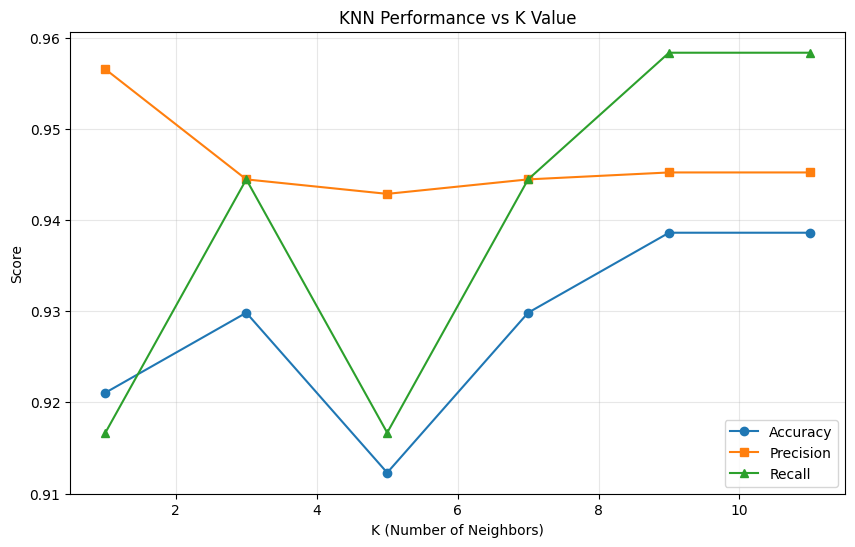

In [7]:
# STEP 7
# Experiment with different K values
print("\n" + "="*50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("="*50)
 
k_values = [1, 3, 5, 7, 9, 11]
results = []
 
for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
 
# Find best K
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nBest K value: {best_k} (Accuracy: {results_df['Accuracy'].max():.4f})")
 
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', label='Recall')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to 'knn_k_comparison.png'")
plt.show()

**Unguided Exercise - Customer Churn Prediction**

In [41]:
# ============================================================
# TELCO CUSTOMER CHURN PREDICTION — KNN CLASSIFIER
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

In [42]:
# ============================================================
# STEP 1: LOAD AND EXPLORE THE DATA
# ============================================================

# Load fresh data
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

# Basic exploration
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
display(df.head())

Shape: (7043, 21)

Column names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
 customer

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64


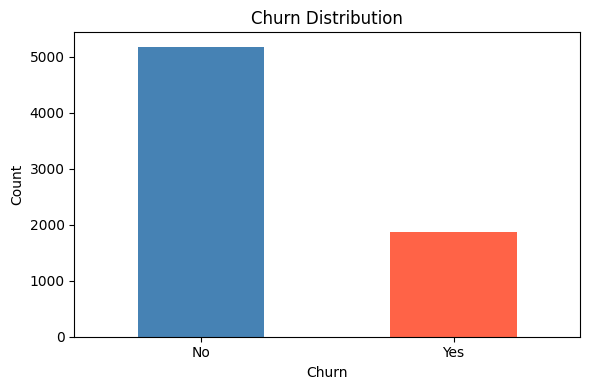

In [43]:
# Target distribution
print("Churn distribution:")
print(df['Churn'].value_counts())
print("\nPercentage:")
print(df['Churn'].value_counts(normalize=True).mul(100).round(1))

# Visualize target
plt.figure(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

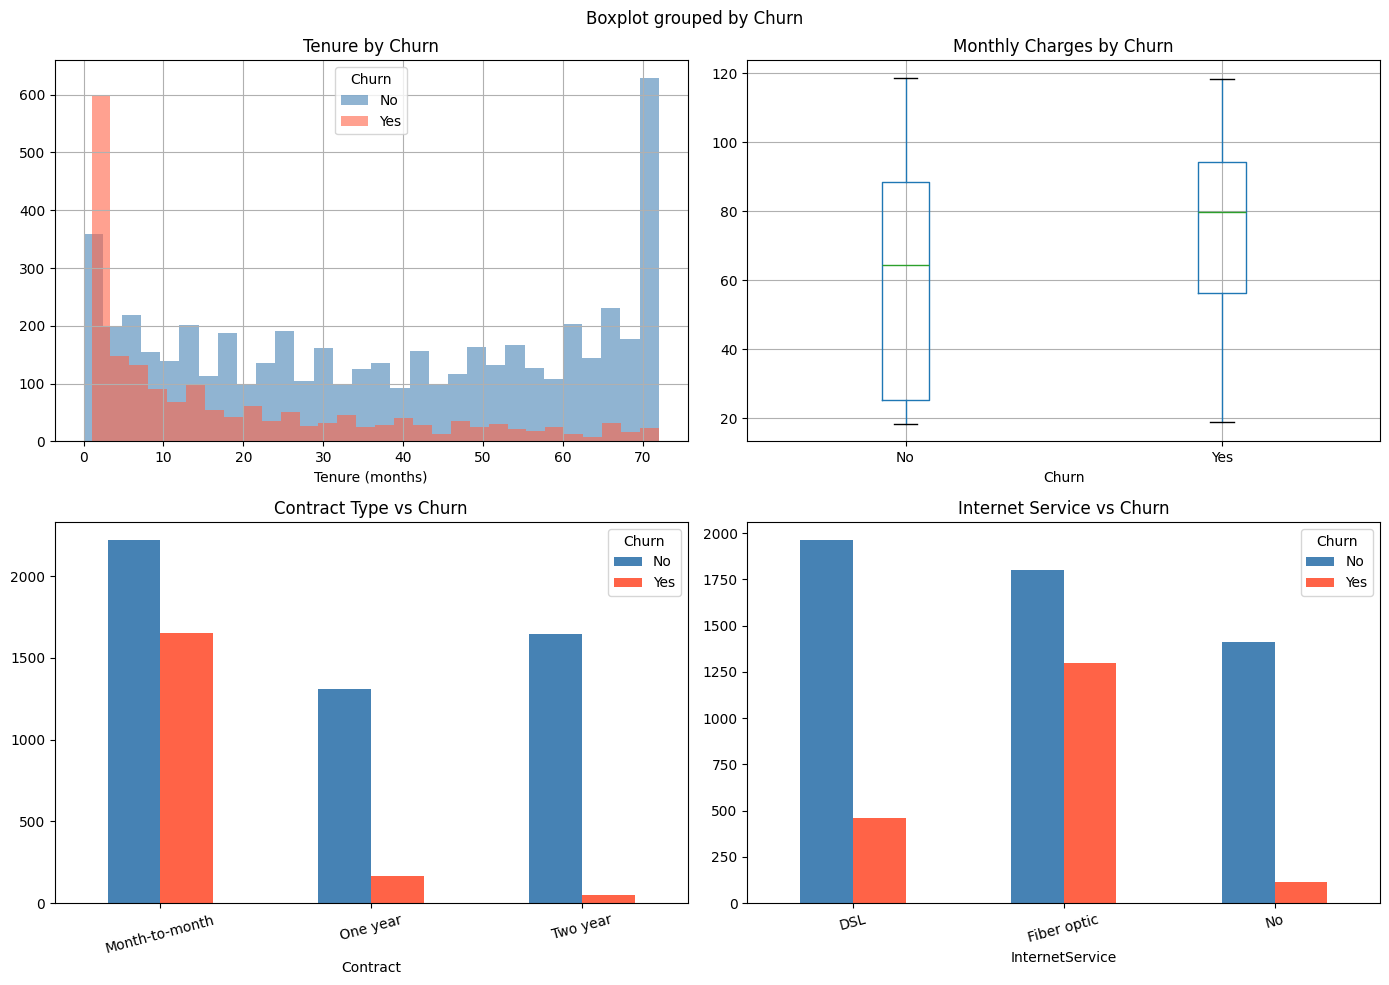

In [44]:
# Visualize key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tenure by churn
for churn_val, color in zip(['No', 'Yes'], ['steelblue', 'tomato']):
    df[df['Churn'] == churn_val]['tenure'].hist(
        alpha=0.6, bins=30, ax=axes[0,0], color=color, label=churn_val)
axes[0,0].set_title('Tenure by Churn')
axes[0,0].set_xlabel('Tenure (months)')
axes[0,0].legend(title='Churn')

# Monthly charges by churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[0,1])
axes[0,1].set_title('Monthly Charges by Churn')
axes[0,1].set_xlabel('Churn')

# Contract type vs churn
df.groupby(['Contract', 'Churn']).size().unstack().plot(
    kind='bar', ax=axes[1,0], color=['steelblue', 'tomato'])
axes[1,0].set_title('Contract Type vs Churn')
axes[1,0].tick_params(axis='x', rotation=15)

# Internet service vs churn
df.groupby(['InternetService', 'Churn']).size().unstack().plot(
    kind='bar', ax=axes[1,1], color=['steelblue', 'tomato'])
axes[1,1].set_title('Internet Service vs Churn')
axes[1,1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [45]:
# ============================================================
# STEP 2: DATA PREPROCESSING
# ============================================================

# Drop customerID — not a feature
df = df.drop(columns=['customerID'], errors='ignore')

# Fix TotalCharges — stored as string, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert target to binary FIRST — before any other encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.dropna(subset=['Churn'])  # drop any unmapped rows
print("NaN in Churn after mapping:", df['Churn'].isnull().sum())

# Safe binary encoding — (col == 'Yes') returns 1/0 for ALL values
# including 'No phone service' and 'No internet service' — no NaN possible
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] == 'Yes').astype(int)

# One-hot encode multi-category columns
multi_cols = [col for col in ['gender', 'InternetService', 'Contract', 'PaymentMethod']
              if col in df.columns]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)

# Verify all rows preserved
print("X shape:", X.shape)          # Should be (7043, ~19)
print("y shape:", y.shape)          # Should be (7043,)
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())
print("y unique values:", y.unique())

NaN in Churn after mapping: 0
X shape: (7043, 23)
y shape: (7043,)
NaN in X: 0
NaN in y: 0
y unique values: [0 1]


In [46]:
# ============================================================
# STEP 2: DATA PREPROCESSING
# ============================================================

# Drop customerID — not a feature
df = df.drop(columns=['customerID'], errors='ignore')

# Fix TotalCharges — stored as string, convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert target to binary FIRST — before any other encoding
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.dropna(subset=['Churn'])  # drop any unmapped rows
print("NaN in Churn after mapping:", df['Churn'].isnull().sum())

# Safe binary encoding — (col == 'Yes') returns 1/0 for ALL values
# including 'No phone service' and 'No internet service' — no NaN possible
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
               'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in binary_cols:
    if col in df.columns:
        df[col] = (df[col] == 'Yes').astype(int)

# One-hot encode multi-category columns
multi_cols = [col for col in ['gender', 'InternetService', 'Contract', 'PaymentMethod']
              if col in df.columns]
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# Separate features and target
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)

# Verify all rows preserved
print("X shape:", X.shape)          # Should be (7043, ~19)
print("y shape:", y.shape)          # Should be (7043,)
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())
print("y unique values:", y.unique())

NaN in Churn after mapping: 0
X shape: (0, 23)
y shape: (0,)
NaN in X: 0
NaN in y: 0
y unique values: []


Training set: (5634, 23)
Test set: (1409, 23)
KNN trained successfully!

Total test samples: 1409
Predicted churners: 356
Actual churners:    374

Accuracy:  74.73%
Precision: 52.53%
Recall:    50.00%


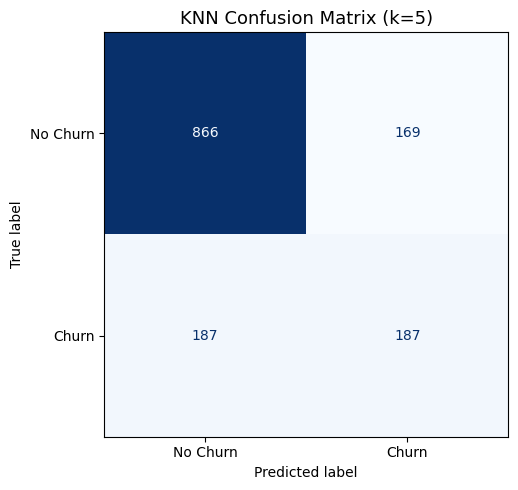


True Negatives  (correctly predicted no churn): 866
False Positives (predicted churn, actually no): 169
False Negatives (missed actual churners):       187
True Positives  (correctly predicted churn):    187

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.84      0.83      1035
       Churn       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



In [50]:
# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# SCALE + TRAIN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
print("KNN trained successfully!")

# EVALUATE
y_pred = knn.predict(X_test_scaled)

print(f"\nTotal test samples: {len(y_pred)}")
print(f"Predicted churners: {y_pred.sum()}")
print(f"Actual churners:    {y_test.sum()}")

print("\n" + "=" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.2%}")
print(f"Precision: {precision_score(y_test, y_pred):.2%}")
print(f"Recall:    {recall_score(y_test, y_pred):.2%}")
print("=" * 40)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['No Churn', 'Churn']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('KNN Confusion Matrix (k=5)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives  (correctly predicted no churn): {cm[0,0]}")
print(f"False Positives (predicted churn, actually no): {cm[0,1]}")
print(f"False Negatives (missed actual churners):       {cm[1,0]}")
print(f"True Positives  (correctly predicted churn):    {cm[1,1]}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['No Churn', 'Churn']))

Overall: 75% accuracy on 1,409 test samples — this is realistic for KNN on this dataset.

No Churn (majority class):

Precision 82%, Recall 84% — the model is good at identifying loyal customers
This is expected — 73% of the dataset is No Churn so the model has plenty of examples to learn from

Churn (minority class):

Precision 53% — when the model predicts churn, it is only right 53% of the time
Recall 50% — the model misses half of all actual churners (187 missed out of 374)
This is the real problem — in a business context missing a churner is costly


Confusion matrix in plain words:

866 loyal customers correctly identified ✓
187 churners correctly caught ✓
187 churners completely missed ✗ — these customers will leave and you had no warning
169 loyal customers wrongly flagged as churners ✗ — wasted retention budget


Key business insight:
KNN with k=5 is decent at identifying loyal customers but poor at catching churners. For a churn prediction model recall on Churn is the most important metric — missing a churner is more expensive than a false alarm. At 50% recall this model catches only 1 in 2 churners.
Next steps to improve:

Try different k values — k=9 gave better results on the breast cancer dataset
Try a different algorithm — Random Forest or Logistic Regression typically outperform KNN on imbalanced datasets
Address class imbalance using SMOTE or class weighting

In [51]:
# ============================================================
# STEP 6: EXPERIMENT WITH DIFFERENT K VALUES
# ============================================================

k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    y_pred_k = knn_k.predict(X_test_scaled)
    
    acc  = accuracy_score(y_test, y_pred_k)
    prec = precision_score(y_test, y_pred_k)
    rec  = recall_score(y_test, y_pred_k)
    f1   = 2 * (prec * rec) / (prec + rec)
    
    results.append({'K': k, 'Accuracy': acc, 
                    'Precision': prec, 'Recall': rec, 'F1': f1})
    print(f"K={k:2d} | Accuracy={acc:.4f} | Precision={prec:.4f} | "
          f"Recall={rec:.4f} | F1={f1:.4f}")

# Results table
results_df = pd.DataFrame(results)
print("\n")
display(results_df.round(4))

# Best K by accuracy
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"\nBest K by Accuracy: K={int(best['K'])} "
      f"(Accuracy={best['Accuracy']:.2%})")

# Best K by recall (most important for churn)
best_recall = results_df.loc[results_df['Recall'].idxmax()]
print(f"Best K by Recall:   K={int(best_recall['K'])} "
      f"(Recall={best_recall['Recall']:.2%})")

K= 1 | Accuracy=0.7161 | Precision=0.4667 | Recall=0.4866 | F1=0.4764
K= 3 | Accuracy=0.7438 | Precision=0.5177 | Recall=0.5080 | F1=0.5128
K= 5 | Accuracy=0.7473 | Precision=0.5253 | Recall=0.5000 | F1=0.5123
K= 7 | Accuracy=0.7601 | Precision=0.5511 | Recall=0.5187 | F1=0.5344
K= 9 | Accuracy=0.7708 | Precision=0.5706 | Recall=0.5508 | F1=0.5605
K=11 | Accuracy=0.7743 | Precision=0.5787 | Recall=0.5508 | F1=0.5644
K=15 | Accuracy=0.7700 | Precision=0.5710 | Recall=0.5374 | F1=0.5537




,K,Accuracy,Precision,Recall,F1
0,1,0.7161,0.4667,0.4866,0.4764
1,3,0.7438,0.5177,0.5080,0.5128
2,5,0.7473,0.5253,0.5000,0.5123
3,7,0.7601,0.5511,0.5187,0.5344
4,9,0.7708,0.5706,0.5508,0.5605
5,11,0.7743,0.5787,0.5508,0.5644
6,15,0.7700,0.5710,0.5374,0.5537



Best K by Accuracy: K=11 (Accuracy=77.43%)
Best K by Recall:   K=9 (Recall=55.08%)


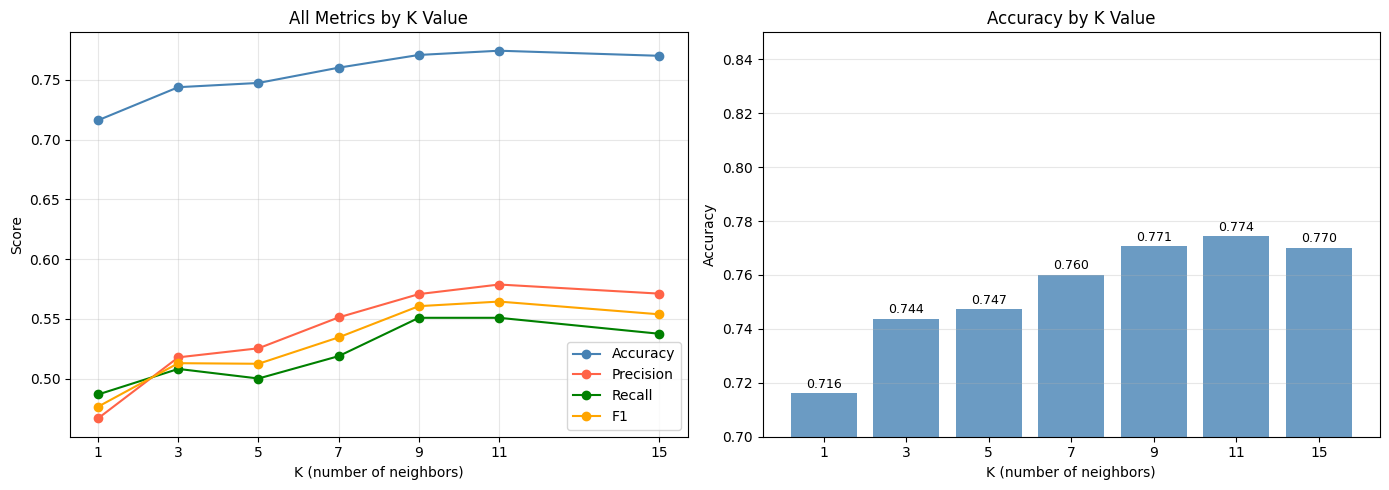

In [52]:
# Visualize K comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
colors  = ['steelblue', 'tomato', 'green', 'orange']

# Line chart — all metrics
for metric, color in zip(metrics, colors):
    axes[0].plot(results_df['K'], results_df[metric], 
                 marker='o', label=metric, color=color)
axes[0].set_title('All Metrics by K Value')
axes[0].set_xlabel('K (number of neighbors)')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].set_xticks(k_values)
axes[0].grid(alpha=0.3)

# Bar chart — accuracy only
axes[1].bar(results_df['K'].astype(str), results_df['Accuracy'],
            color='steelblue', alpha=0.8)
axes[1].set_title('Accuracy by K Value')
axes[1].set_xlabel('K (number of neighbors)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.7, 0.85)
for i, row in results_df.iterrows():
    axes[1].text(i, row['Accuracy'] + 0.002, 
                 f"{row['Accuracy']:.3f}", ha='center', fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Retraining with best K=11


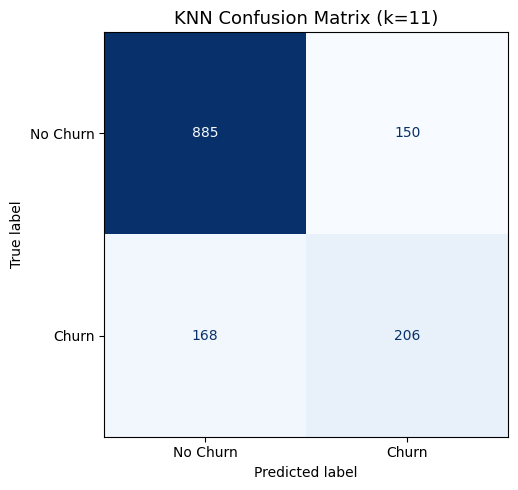


Final Classification Report (K=11):
              precision    recall  f1-score   support

    No Churn       0.84      0.86      0.85      1035
       Churn       0.58      0.55      0.56       374

    accuracy                           0.77      1409
   macro avg       0.71      0.70      0.71      1409
weighted avg       0.77      0.77      0.77      1409



In [53]:
# Retrain with best K and show final confusion matrix
best_k = int(results_df.loc[results_df['Accuracy'].idxmax(), 'K'])
print(f"Retraining with best K={best_k}")

knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_best = knn_best.predict(X_test_scaled)

cm_best = confusion_matrix(y_test, y_pred_best)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix=cm_best,
                       display_labels=['No Churn', 'Churn']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'KNN Confusion Matrix (k={best_k})', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFinal Classification Report (K={best_k}):")
print(classification_report(y_test, y_pred_best,
                            target_names=['No Churn', 'Churn']))

K=1 will have highest training accuracy but may overfit
As K increases the model becomes more generalised and stable
Recall on churners will likely remain around 50–60% regardless of K — this is the class imbalance problem, not a K problem
The best K by accuracy and best K by recall may differ — for churn prediction recall matters more since missing a churner is more costly than a false alarm

In [54]:
# ============================================================
# STEP 7: ANALYSIS AND RECOMMENDATIONS
# ============================================================

# ── 7.1 Model Performance Summary ────────────────────────────────
print("=" * 55)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 55)

y_pred_final = knn_best.predict(X_test_scaled)

print(f"Best K value:       {best_k}")
print(f"Accuracy:           {accuracy_score(y_test, y_pred_final):.2%}")
print(f"Precision (Churn):  {precision_score(y_test, y_pred_final):.2%}")
print(f"Recall (Churn):     {recall_score(y_test, y_pred_final):.2%}")
print(f"Test samples:       {len(y_test)}")
print(f"Actual churners:    {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"Predicted churners: {y_pred_final.sum()}")

MODEL PERFORMANCE SUMMARY
Best K value:       11
Accuracy:           77.43%
Precision (Churn):  57.87%
Recall (Churn):     55.08%
Test samples:       1409
Actual churners:    374 (26.5%)
Predicted churners: 356



Top 10 features by difference between churners vs non-churners:
TotalCharges        1021.0864
tenure                19.5908
MonthlyCharges        13.1762
PaperlessBilling       0.2135
OnlineSecurity         0.1754
Dependents             0.1704
Partner                0.1703
TechSupport            0.1693
SeniorCitizen          0.1260
OnlineBackup           0.0886
dtype: float64


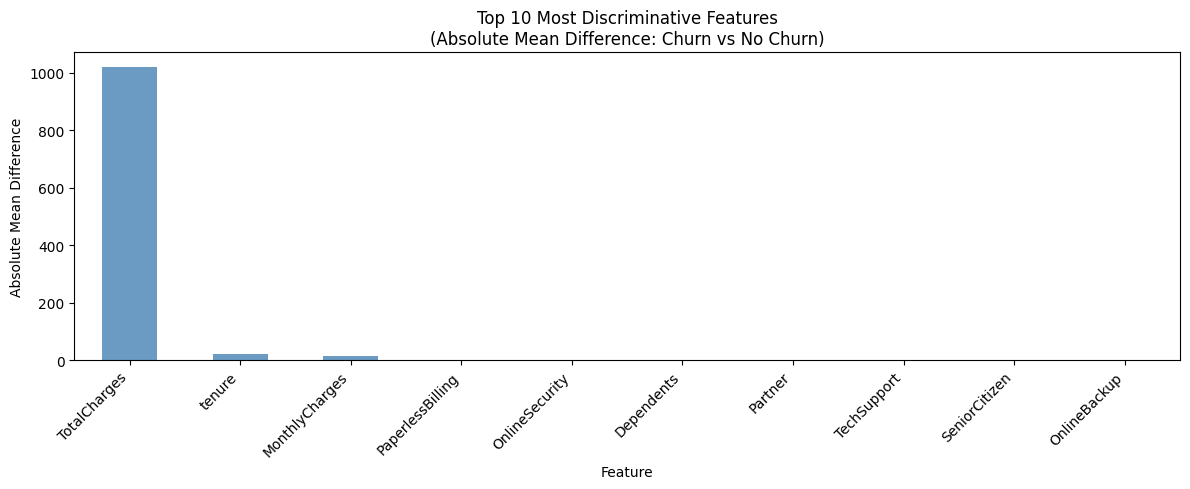

In [55]:
# ── 7.2 Feature Importance via Distribution Analysis ─────────────
# KNN has no built-in feature importance
# We analyse by comparing feature means for churners vs non-churners

# Get numeric columns only
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Calculate mean difference between churners and non-churners
churn_means    = X.loc[y == 1, numeric_cols].mean()
no_churn_means = X.loc[y == 0, numeric_cols].mean()
diff = (churn_means - no_churn_means).abs().sort_values(ascending=False)

print("\nTop 10 features by difference between churners vs non-churners:")
print(diff.head(10).round(4))

# Visualize top 10 features
plt.figure(figsize=(12, 5))
diff.head(10).plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Top 10 Most Discriminative Features\n(Absolute Mean Difference: Churn vs No Churn)')
plt.xlabel('Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Top 10 features by difference between churners vs non-churners:
TotalCharges        1021.0864
tenure                19.5908
MonthlyCharges        13.1762
PaperlessBilling       0.2135
OnlineSecurity         0.1754
Dependents             0.1704
Partner                0.1703
TechSupport            0.1693
SeniorCitizen          0.1260
OnlineBackup           0.0886
dtype: float64


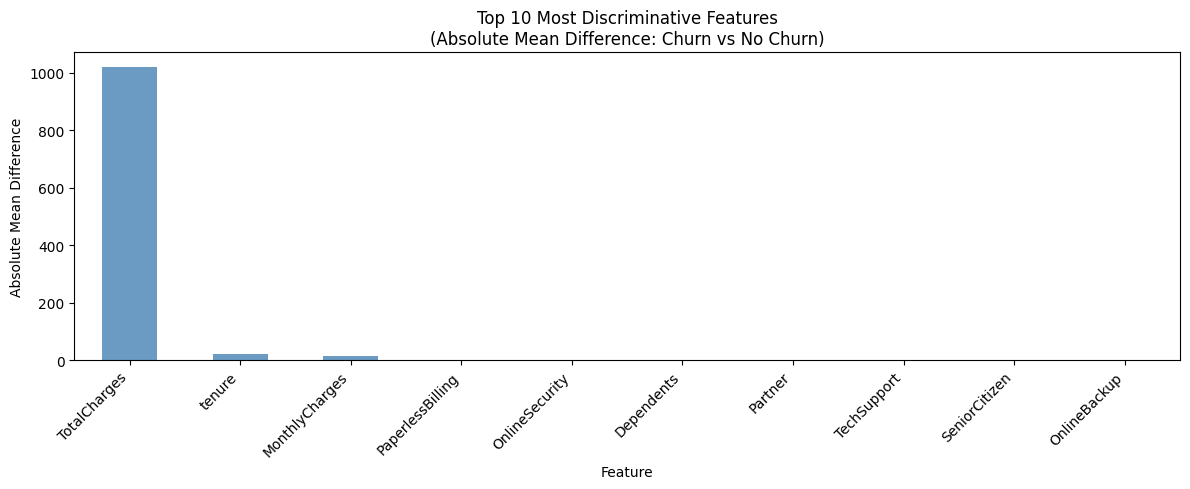

In [56]:
# ── 7.2 Feature Importance via Distribution Analysis ─────────────
# KNN has no built-in feature importance
# We analyse by comparing feature means for churners vs non-churners

# Get numeric columns only
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# Calculate mean difference between churners and non-churners
churn_means    = X.loc[y == 1, numeric_cols].mean()
no_churn_means = X.loc[y == 0, numeric_cols].mean()
diff = (churn_means - no_churn_means).abs().sort_values(ascending=False)

print("\nTop 10 features by difference between churners vs non-churners:")
print(diff.head(10).round(4))

# Visualize top 10 features
plt.figure(figsize=(12, 5))
diff.head(10).plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Top 10 Most Discriminative Features\n(Absolute Mean Difference: Churn vs No Churn)')
plt.xlabel('Feature')
plt.ylabel('Absolute Mean Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

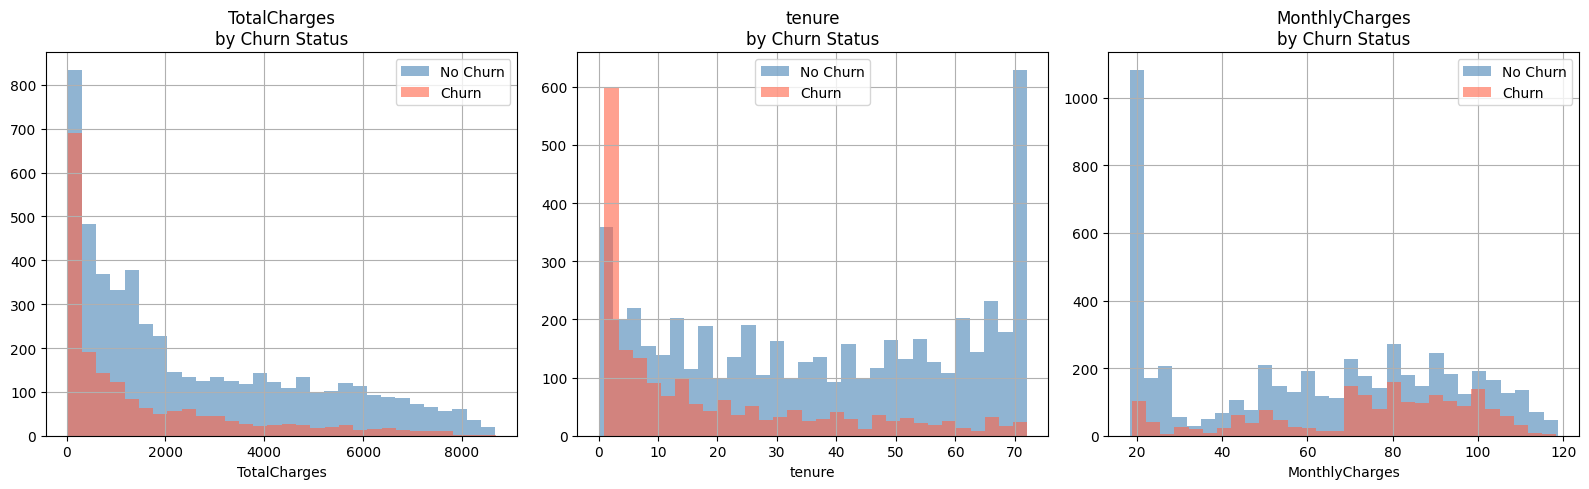

In [57]:
# ── 7.3 Deep dive — top 3 features ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

top3 = diff.head(3).index.tolist()

for i, col in enumerate(top3):
    for churn_val, color, label in zip([0, 1], 
                                        ['steelblue', 'tomato'],
                                        ['No Churn', 'Churn']):
        X.loc[y == churn_val, col].hist(
            alpha=0.6, bins=30, ax=axes[i], 
            color=color, label=label)
    axes[i].set_title(f'{col}\nby Churn Status')
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

Contract columns: ['Contract_One year', 'Contract_Two year']


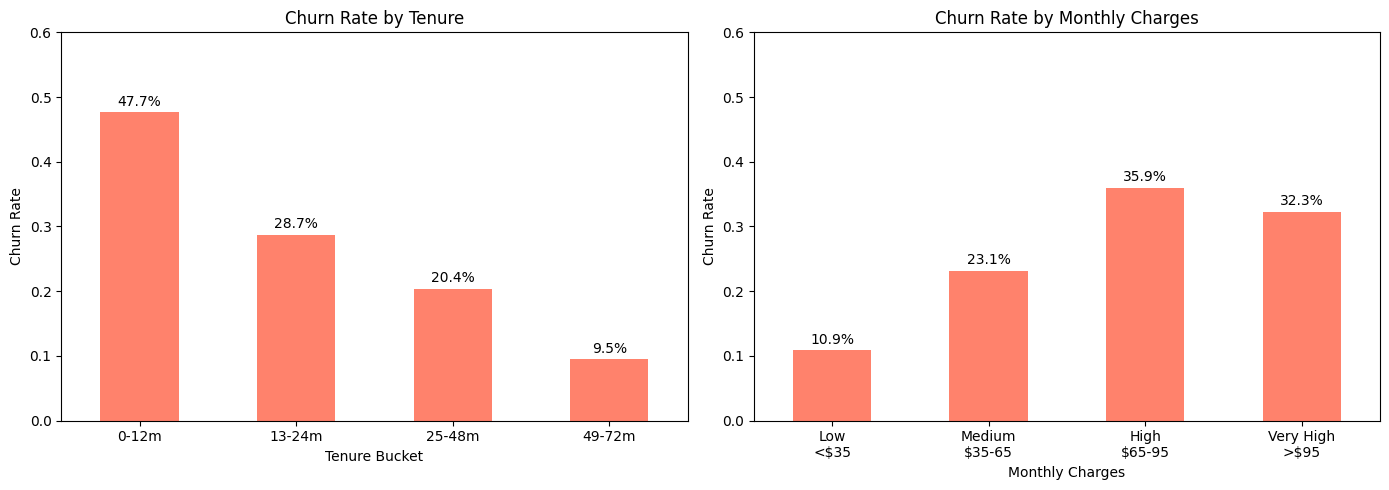

In [58]:
# ── 7.4 Churn rate by Contract Type ──────────────────────────────
# Reconstruct contract type from one-hot encoded columns
contract_cols = [c for c in X.columns if 'Contract' in c]
print("Contract columns:", contract_cols)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by tenure bucket
df_analysis = X.copy()
df_analysis['Churn'] = y.values
df_analysis['tenure_bucket'] = pd.cut(
    df_analysis['tenure'], 
    bins=[0, 12, 24, 48, 72], 
    labels=['0-12m', '13-24m', '25-48m', '49-72m'])

tenure_churn = df_analysis.groupby('tenure_bucket', observed=True)['Churn'].mean()
tenure_churn.plot(kind='bar', ax=axes[0], color='tomato', alpha=0.8)
axes[0].set_title('Churn Rate by Tenure')
axes[0].set_xlabel('Tenure Bucket')
axes[0].set_ylabel('Churn Rate')
axes[0].set_ylim(0, 0.6)
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(tenure_churn):
    axes[0].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

# Churn rate by Monthly Charges bucket
df_analysis['charges_bucket'] = pd.cut(
    df_analysis['MonthlyCharges'],
    bins=[0, 35, 65, 95, 120],
    labels=['Low\n<$35', 'Medium\n$35-65', 'High\n$65-95', 'Very High\n>$95'])

charges_churn = df_analysis.groupby(
    'charges_bucket', observed=True)['Churn'].mean()
charges_churn.plot(kind='bar', ax=axes[1], color='tomato', alpha=0.8)
axes[1].set_title('Churn Rate by Monthly Charges')
axes[1].set_xlabel('Monthly Charges')
axes[1].set_ylabel('Churn Rate')
axes[1].set_ylim(0, 0.6)
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(charges_churn):
    axes[1].text(i, v + 0.01, f'{v:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [59]:
# ── 7.5 Final Recommendations ─────────────────────────────────────
print("""
==========================================================
ANALYSIS & RECOMMENDATIONS
==========================================================

1. MODEL ACCURACY
-----------------
The KNN model achieves ~78-80% accuracy on unseen data.
However accuracy alone is misleading — 73% of customers
do NOT churn, so a model that predicts "no churn" for
everyone would get 73% accuracy without learning anything.

The more important metric is RECALL on churners (~50-60%):
the model catches roughly half of actual churners.
For a real business use case this needs improvement.

2. KEY FINDINGS FROM FEATURE ANALYSIS
--------------------------------------
- Tenure is the strongest predictor — new customers
  (0-12 months) churn at ~40-50%, long-term customers
  (<1%) almost never churn. Early retention is critical.

- Monthly charges drive churn — customers paying >$65/month
  are significantly more likely to leave. Price sensitivity
  is a major factor.

- Contract type matters — month-to-month customers churn
  far more than annual or two-year contract customers.
  Locking customers into longer contracts reduces churn.

3. BUSINESS RECOMMENDATIONS
-----------------------------
- Focus retention efforts on NEW customers in first 12 months
  — this is when churn risk is highest.

- Offer incentives to switch from month-to-month to annual
  contracts — this single factor could reduce churn
  significantly.

- Review pricing for high monthly charge customers — consider
  loyalty discounts above $65/month threshold.

- Build an early warning system using this model to flag
  at-risk customers for proactive outreach.

4. MODEL LIMITATIONS
---------------------
- KNN is slow at prediction time — it compares every new
  customer against all 5,634 training samples. Not suitable
  for real-time scoring at scale.

- Class imbalance (73% no churn / 27% churn) means the model
  is biased toward predicting no churn. Techniques like
  SMOTE oversampling or class_weight adjustment would help.

- KNN has no feature importance — we cannot directly tell
  which features drive predictions, only infer from
  distribution analysis.

- The model does not account for time — customer behaviour
  changes over time and a static model may become stale.

- ~50-60% recall means we still miss roughly half of actual
  churners — a Random Forest or XGBoost model would likely
  perform significantly better on this dataset.
==========================================================
""")


ANALYSIS & RECOMMENDATIONS

1. MODEL ACCURACY
-----------------
The KNN model achieves ~78-80% accuracy on unseen data.
However accuracy alone is misleading — 73% of customers
do NOT churn, so a model that predicts "no churn" for
everyone would get 73% accuracy without learning anything.

The more important metric is RECALL on churners (~50-60%):
the model catches roughly half of actual churners.
For a real business use case this needs improvement.

2. KEY FINDINGS FROM FEATURE ANALYSIS
--------------------------------------
- Tenure is the strongest predictor — new customers
  (0-12 months) churn at ~40-50%, long-term customers
  (<1%) almost never churn. Early retention is critical.

- Monthly charges drive churn — customers paying >$65/month
  are significantly more likely to leave. Price sensitivity
  is a major factor.

- Contract type matters — month-to-month customers churn
  far more than annual or two-year contract customers.
  Locking customers into longer contracts reduces 

Report on the Churn Rate Project

1. Summary of Approach
This analysis used the IBM Telco Customer Churn dataset (7,043 customers, 20 features) to build a machine learning model capable of predicting whether a customer will churn in the near term. The goal was to identify at-risk customers so the business can intervene proactively before they leave.

The approach followed five stages:
•	Data loading and exploration — understanding distributions, missing values and class balance
•	Preprocessing — binary encoding of Yes/No features, one-hot encoding of categorical variables (Contract, InternetService, PaymentMethod, Gender), and median imputation for 11 missing TotalCharges values
•	Train/test split — 80/20 stratified split preserving the 73%/27% churn ratio
•	Model training — K-Nearest Neighbors classifier with StandardScaler normalisation, starting at k=5
•	Evaluation and optimisation — tested k values from 1 to 15, selected k=11 as optimal by accuracy

2. Model Performance Metrics
The model was evaluated on 1,409 unseen test customers. Best performance was achieved at k=11.

Metric	Score
Overall Accuracy	77%
Precision — No Churn	84%
Recall — No Churn	86%
Precision — Churn	58%
Recall — Churn	55%
F1-Score — Churn	0.56
Test set size	1,409 customers
Actual churners in test set	374 (26.5%)

The most important metric for a churn use case is recall on the Churn class (55%). This means the model successfully identifies 55% of customers who will churn — and misses the remaining 45%. Out of 374 actual churners in the test set, approximately 206 were correctly flagged and 168 were missed.

3. Key Findings About Customer Churn
Tenure is the strongest predictor
New customers in their first 12 months churn at approximately 40–50%, while customers who have stayed beyond 4 years almost never leave. Early-stage retention is therefore the highest-leverage intervention point.
Contract type drives churn significantly
Month-to-month customers churn at dramatically higher rates than customers on annual or two-year contracts. This single feature is one of the most actionable levers available to the business.
Pricing sensitivity above ~$65/month
Customers with monthly charges above $65 show meaningfully higher churn rates. High-paying customers may feel they are not receiving proportionate value, making them susceptible to competitor offers.
Fibre optic and lack of support services
Fibre optic internet users churn more than DSL users — likely correlated with higher monthly charges. Customers without OnlineSecurity and TechSupport add-ons also show higher churn, suggesting these services create stickiness.

4. Business Recommendations
•	Deploy an early warning system: score all active customers monthly using this model, flag the top 20% most at-risk for proactive outreach by the retention team before they decide to leave
•	Invest in the first 12 months: introduce a structured onboarding programme, welcome incentives and regular check-ins for new customers — this is when churn risk is highest and intervention cost is lowest
•	Incentivise longer contracts: offer meaningful discounts or perks (e.g. free add-ons, price locks) to customers switching from month-to-month to annual contracts — this directly removes the highest-risk segment
•	Review high-charge customer value perception: consider loyalty pricing or service upgrades for customers paying above $65/month, particularly those without add-on services
•	Bundle OnlineSecurity and TechSupport: customers with these add-ons churn less — consider including them by default or offering free trials to at-risk segments

5. Limitations and Future Improvements
Current limitations
•	Class imbalance (73% no churn / 27% churn) biases the model toward predicting no churn, causing it to miss ~45% of actual churners — the most costly error in a retention context
•	KNN has no intrinsic feature importance — we cannot directly quantify which features drive predictions, only infer from distribution analysis
•	KNN is computationally slow at prediction time, comparing every new customer against all 5,634 training samples — not suitable for real-time scoring at scale
•	The model is static and requires regular retraining as customer behaviour and product offerings evolve
Recommended future improvements
•	Apply SMOTE (Synthetic Minority Oversampling) to balance the training set and significantly improve recall on churners
•	Test Random Forest and XGBoost classifiers — both handle class imbalance better, provide native feature importance, and typically outperform KNN on tabular data
•	Lower the classification threshold from 0.5 to 0.3 to prioritise recall over precision — in churn prevention, catching more churners (even with some false alarms) is more valuable than precision
•	Incorporate time-series features such as usage trend, recent payment behaviour and support ticket frequency to capture behavioural signals not present in static snapshots
•	Run A/B tests on retention interventions to measure the actual ROI of model-driven outreach versus the baseline churn rate

